In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from scipy.ndimage import gaussian_filter
import seaborn as sns

path = '/Volumes/Elements/PTM_project/GGTC/unbiased_1us/'

In [3]:
chains = ['A','B']
colors = ['blue','red','orange']
nsims=3

avg = []
err = []

for i in range(len(chains)):
    
    vals = []
    
    for s in range(1,nsims+1):
    
        dat = np.loadtxt(path+"sim{}/sasa_chain{}_SER136.xvg".format(s,chains[i]),skiprows=25)
    
        sasa = dat[:,2]
        time = dat[:,0]/1000 # convert to nanoseconds
        
        vals.append(np.mean(sasa)) 

    avg.append(np.mean(vals))
    err.append(np.std(vals)/np.sqrt(nsims))
    
df = pd.DataFrame()
df['Chain'] = chains
df['SASA (nm$^{2}$)'] = avg
df['Error'] = err

df.to_csv('avg_SC_SASA_SER136.csv')
df

,Chain,SASA (nm$^{2}$),Error
0,A,0.017290,0.003314
1,B,0.030912,0.008936


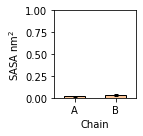

In [5]:
# plot
df = pd.read_csv('avg_SC_SASA_SER136.csv')
df.plot(x='Chain',y='SASA (nm$^{2}$)',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,1)

plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SER_SASA_barplot.pdf')

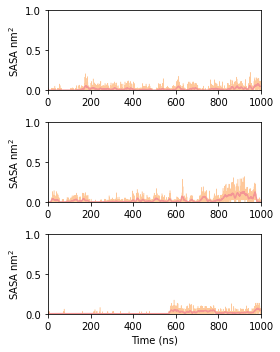

In [7]:
# individual simulation plots of the buried PTMs


nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    dat = np.loadtxt(path+"sim{}/sasa_chainA_SER136.xvg".format(s),skiprows=25)[::10] # downsample 10k, 200 ps frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,1)
    plt.xlim(0,1000)

    if s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_SER136_chainA.pdf')


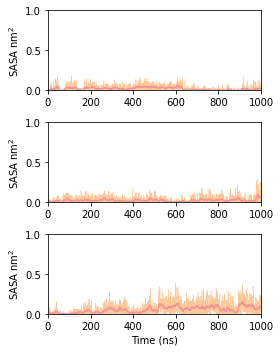

In [8]:
# individual simulation plots of the buried PTMs


nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    dat = np.loadtxt(path+"sim{}/sasa_chainB_SER136.xvg".format(s),skiprows=25)[::10] # downsample 10k, 200 ps frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,1)
    plt.xlim(0,1000)

    if s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_SER136_chainB.pdf')



In [12]:
# 2D histogram of SASA vs cterm RMSD (chain A and chain B - 6 us total)

chains = ['A','B']
nsims=3

SASA = np.array([])
RMSD = np.array([])

for i in range(len(chains)):
    
    vals = []
    
    for s in range(1,nsims+1):
    
        sasa = np.loadtxt(path+"sim{}/sasa_chain{}_SER136.xvg".format(s,chains[i]),skiprows=25)[:,2]
        cterm = np.loadtxt(path+"sim{}/cterm_chain{}_RMSD.xvg".format(s,chains[i]),skiprows=18)[:,1]
        
        SASA = np.append(SASA,sasa)
        RMSD = np.append(RMSD,cterm)
    
        
SASA.shape

(300006,)

In [13]:
RMSD.shape

(300006,)

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in log
  from ipykernel import kernelapp as app


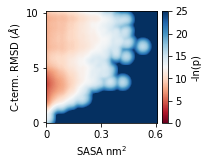

In [68]:
# 2D histogram

# convergence with rbias reweighting BF15

xedges = np.arange(0,0.606,0.006) # sasa
yedges = np.arange(0,10.1,0.1) # rmsd



H, xedges, yedges = np.histogram2d(SASA, RMSD*10,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H)
h = h.T

h = -np.log(h)
h = np.nan_to_num(h,posinf=100)
#h = h - np.min(h)

max_energy = 1.0

plt.figure(figsize = (3,3))

plt.imshow(h,origin='lower',cmap='RdBu')
plt.clim(0,25)
plt.colorbar(fraction=0.046, pad=0.04,label = '-ln(p)')
xlabels = [0,0.3,0.6]
ylabels = [0,5,10]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,49,98],labels =ylabels)

#plt.contour(h,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                #linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))

plt.xlabel('SASA nm$^{2}$')
plt.ylabel('C-term. RMSD ($\\AA$)')

plt.tight_layout()
plt.savefig('2D_sasaS136_cterm_rmsd.pdf')

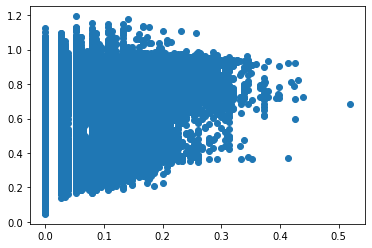

In [38]:
plt.scatter(SASA,RMSD)

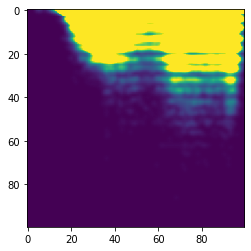

In [39]:
plt.imshow(H)
plt.clim(0,10)

<AxesSubplot:ylabel='Density'>

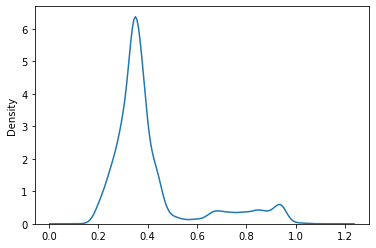

In [31]:
sns.kdeplot(RMSD)

In [53]:
h

array([[15.79826445, 16.03274022, 16.50216281, ...,         inf,
                inf,         inf],
       [15.03984825, 15.27432402, 15.74374661, ...,         inf,
                inf,         inf],
       [14.29345559, 14.52793136, 14.99735395, ...,         inf,
                inf,         inf],
       ...,
       [ 8.46822925,  8.61871465,  8.8483528 , ...,         inf,
                inf,         inf],
       [ 8.77949608,  8.9342401 ,  9.17438286, ...,         inf,
                inf,         inf],
       [ 8.99594512,  9.15407176,  9.40264627, ...,         inf,
                inf,         inf]])